In [2]:
import pandas as pd

pheno0 = pd.read_csv("results/Biomarker-Projection-Phenotype-0.csv")
pheno1 = pd.read_csv("results/Biomarker-Projection-Phenotype-1.csv")

In [3]:
# Calculate mortality rate for each phenotype
mortality_pheno0 = pheno0['died_in_hospital'].mean() * 100  # percent
mortality_pheno1 = pheno1['died_in_hospital'].mean() * 100

print(f"Phenotype 0 mortality: {mortality_pheno0:.2f}%")
print(f"Phenotype 1 mortality: {mortality_pheno1:.2f}%")

# Difference
diff = abs(mortality_pheno0 - mortality_pheno1)
print(f"Absolute difference: {diff:.2f}%")


Phenotype 0 mortality: 6.11%
Phenotype 1 mortality: 13.71%
Absolute difference: 7.60%


In [4]:
from scipy.stats import chi2_contingency

# Build contingency table
dead_0 = pheno0['died_in_hospital'].sum()
alive_0 = len(pheno0) - dead_0

dead_1 = pheno1['died_in_hospital'].sum()
alive_1 = len(pheno1) - dead_1

table = [[dead_0, alive_0],
         [dead_1, alive_1]]

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-squared test p-value: {p:.4f}")


Chi-squared test p-value: 0.0000


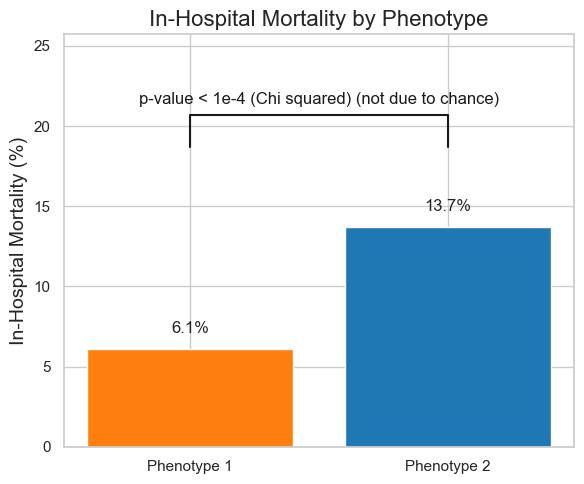

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mortality percentages you calculated
mortality_pheno0 = pheno0['died_in_hospital'].mean() * 100
mortality_pheno1 = pheno1['died_in_hospital'].mean() * 100

# Prepare data for plotting
phenotypes = ['Phenotype 1', 'Phenotype 2']
mortality_rates = [mortality_pheno0, mortality_pheno1]

# Plot setup
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))

bars = plt.bar(
    phenotypes,
    mortality_rates,
    color=["tab:orange","tab:blue"]
)

# Add text labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', fontsize=12)

# Add significance annotation (p < 0.0001)
x1, x2 = 0, 1  # positions of bars
y, h, col = max(mortality_rates) + 5, 2, 'k'

ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
ax.text((x1+x2)*.5, y+h + 0.5, "p-value < 1e-4 (Chi squared) (not due to chance)", ha='center', va='bottom', color=col, fontsize=12)

# Labels and title
ax.set_ylabel('In-Hospital Mortality (%)', fontsize=14)
ax.set_title('In-Hospital Mortality by Phenotype', fontsize=16)
ax.set_ylim(0, y + h + 5)

plt.tight_layout()
plt.show()


Phenotype 1 mortality: 6.11%
Phenotype 2 mortality: 13.71%
Absolute difference: 7.60%


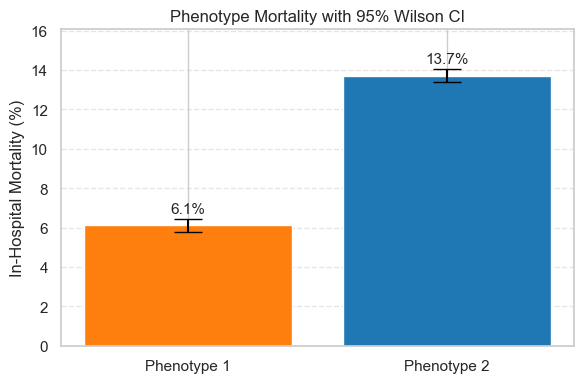

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
pheno0 = pd.read_csv("results/Biomarker-Projection-Phenotype-0.csv")
pheno1 = pd.read_csv("results/Biomarker-Projection-Phenotype-1.csv")

# Mortality as proportions
p0 = pheno0["died_in_hospital"].mean()
p1 = pheno1["died_in_hospital"].mean()

n0, n1 = len(pheno0), len(pheno1)

print(f"Phenotype 1 mortality: {p0*100:.2f}%")
print(f"Phenotype 2 mortality: {p1*100:.2f}%")
print(f"Absolute difference: {abs(p0-p1)*100:.2f}%")

# ----------------------------
# Wilson confidence interval
# ----------------------------
def wilson_ci(p, n, z=1.96):
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return center - half, center + half

ci0_low, ci0_high = wilson_ci(p0, n0)
ci1_low, ci1_high = wilson_ci(p1, n1)

# Convert to percentages for plotting
mortality_pct = [p0*100, p1*100]

ci_lower = [(p0 - ci0_low)*100, (p1 - ci1_low)*100]
ci_upper = [(ci0_high - p0)*100, (ci1_high - p1)*100]

# ----------------------------
# Plot
# ----------------------------
clusters = ["Phenotype 1", "Phenotype 2"]
colors = ["tab:orange", "tab:blue"]  # light blue, light orange

plt.figure(figsize=(6, 4))
plt.bar(
    clusters,
    mortality_pct,
    yerr=[ci_lower, ci_upper],
    capsize=10,
    color=colors,
    error_kw=dict(ecolor="black", lw=1.5)
)

plt.ylabel("In-Hospital Mortality (%)")
plt.title("Phenotype Mortality with 95% Wilson CI")
plt.ylim(0, max(mortality_pct) + max(ci_upper) + 2)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate bars
for i, rate in enumerate(mortality_pct):
    plt.text(
        i,
        rate + ci_upper[i] + 0.3,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()
